# Network Sim Correlation

The following are attempts to correlate the network model in accelforge to actual networks measured in real architectures.

In [1]:
import accelforge as af
import matplotlib.pyplot as plt

## We are testing an 8 GPU All-to-All to Correlate Later, simulating an NVLink Switch


### Encoding: one-hot GPU coordinates on a fully-connected fabric

GPU $i$ sits at one-hot coordinate $e_i$ of an $N$-dimensional `noc` space. `data[s, d]` is the chunk sent by GPU $s$ to GPU $d$: each GPU *holds* the chunks it sends (occupancy) and *requests* the chunks addressed to it (fill).

Every $s \neq d$ cast then has extent 1 along exactly the src and dst dimensions, so `HypercubeMulticastModel`'s bounding-box cost is $(1+1)(1+1)-1 = 3$ **uniformly for every pair** — the fully-connected property (no pair privileged). The distance function is unit-cost (0 if same GPU, 1 otherwise) and only influences source matching in `identify_mesh_casts`. Self-chunks match at distance 0 and cost 0 hops: they never cross the fabric.

In [2]:
import math

import islpy as isl
import pandas as pd

from accelforge.model._looptree.reuse.isl.distributed.distributed_buffers import (
    HypercubeMulticastModel,
)
from accelforge.model._looptree.reuse.isl.mapping_to_isl.types import (
    Fill,
    Occupancy,
    SpatialTag,
)

CTX = isl.DEFAULT_CONTEXT

In [3]:
def onehot_constraints(prefix: str, n: int) -> str:
    """One-hot constraints over dims ``{prefix}0..{prefix}{n-1}``."""
    bounds = " and ".join(f"0 <= {prefix}{i} <= 1" for i in range(n))
    hot = " + ".join(f"{prefix}{i}" for i in range(n)) + " = 1"
    return f"{bounds} and {hot}"


def linear_id(prefix: str, n: int) -> str:
    """Affine recovery of the GPU id from a one-hot vector: id = sum i*g_i."""
    return " + ".join(f"{i}*{prefix}{i}" for i in range(1, n))


def all_to_all_maps(n: int) -> tuple[isl.Map, isl.Map, isl.Map]:
    """Build (occupancy, fill, dist_fn) for an N-GPU fully-connected all-to-all.

    data[s, d] is the chunk sent by GPU s to GPU d. Each GPU holds the
    chunks it sends (occ) and requests the chunks addressed to it (fill).
    """
    gs = ", ".join(f"gs{i}" for i in range(n))
    gd = ", ".join(f"gd{i}" for i in range(n))
    occ = isl.Map.read_from_str(
        CTX,
        f"{{ noc[{gs}] -> data[s, d] : {onehot_constraints('gs', n)} "
        f"and s = {linear_id('gs', n)} and 0 <= d < {n} }}",
    )
    fill = isl.Map.read_from_str(
        CTX,
        f"{{ noc[{gd}] -> data[s, d] : {onehot_constraints('gd', n)} "
        f"and d = {linear_id('gd', n)} and 0 <= s < {n} }}",
    )

    xd = ", ".join(f"xd{i}" for i in range(n))
    xs = ", ".join(f"xs{i}" for i in range(n))
    same = " and ".join(f"xd{i} = xs{i}" for i in range(n))
    diff = " or ".join(f"(xd{i} < xs{i}) or (xd{i} > xs{i})" for i in range(n))
    dist_fn = isl.Map.read_from_str(
        CTX,
        f"{{ [noc[{xd}] -> noc[{xs}]] -> hops[0] : {same}; "
        f"  [noc[{xd}] -> noc[{xs}]] -> hops[1] : {diff} }}",
    )
    return occ, fill, dist_fn

In [ ]:
def eval_total(poly: isl.PwQPolynomial) -> int:
    """Evaluate a fully-summed PwQPolynomial (zero-dimensional domain)."""
    return int(poly.eval(isl.Point.zero(poly.domain().get_space())).to_python())


def model_hops_per_element(n: int) -> int:
    """Run the real HypercubeMulticastModel on the all-to-all at V=1."""
    occ_map, fill_map, dist_fn = all_to_all_maps(n)
    tags = [SpatialTag(i, 0) for i in range(n)]
    model = HypercubeMulticastModel(dist_fn)
    info = model.apply(0, Fill(tags, fill_map), Occupancy(tags, occ_map))
    return eval_total(info.hops)


def single_chunk_hops(n: int, src: int, dst: int) -> int:
    """Hops for one (src, dst) chunk — uniformity / self-chunk probe."""
    occ_map, fill_map, dist_fn = all_to_all_maps(n)
    chunk = isl.Set.read_from_str(CTX, f"{{ data[{src}, {dst}] }}")
    tags = [SpatialTag(i, 0) for i in range(n)]
    model = HypercubeMulticastModel(dist_fn)
    info = model.apply(
        0,
        Fill(tags, fill_map.intersect_range(chunk)),
        Occupancy(tags, occ_map.intersect_range(chunk)),
    )
    return eval_total(info.hops)

In [5]:
NODES = 8                    # GPUs on the fabric
LINK_BW_GBPS = 150.0         # per-GPU per-direction NVLink bandwidth, GB/s (V100 generation)
ALPHA_S = 0.0                # per-operation latency overhead, seconds
MIN_MIB, MAX_MIB = 1, 1024   # collective size sweep bounds, powers of 2
PER_RANK = False             # interpret swept sizes as per-rank NCCL sizes instead of totals

In [6]:
n = NODES

# --- Run the tool at V=1 and validate the fully-connected structure. ---
hops_per_elem = model_hops_per_element(n)
expected = 3 * n * (n - 1)
assert hops_per_elem == expected, (
    f"model returned {hops_per_elem} hops/element, expected {expected} "
    f"(= 3 per off-diagonal pair x {n*(n-1)} pairs)"
)
probe_off = single_chunk_hops(n, 0, min(3, n - 1))
probe_self = single_chunk_hops(n, n - 1, n - 1)
assert probe_off == 3, f"off-diagonal chunk cost {probe_off} != 3"
assert probe_self == 0, f"self chunk cost {probe_self} != 0"
crossing_chunks = hops_per_elem // 3  # = N(N-1) fabric-crossing chunks

print(f"ISL network model: {n}-GPU fully-connected all-to-all (one-hot)")
print(f"  hops/element          : {hops_per_elem} (uniform 3 per pair)")
print(f"  fabric-crossing chunks: {crossing_chunks} of {n*n}")

ISL network model: 8-GPU fully-connected all-to-all (one-hot)
  hops/element          : 168 (uniform 3 per pair)
  fabric-crossing chunks: 56 of 64


### Size and latency conventions

`collective_size` $S$ = **total** bytes moved by the collective across all ranks (ASTRA-sim style). Per-rank NCCL buffer size = $S/N$; each $(s, d)$ pair exchanges a chunk of $S/N^2$ bytes. Set `PER_RANK = True` to interpret the swept sizes as per-rank NCCL sizes instead.

Latency derives from the model's hop count: hops are uniform 3 per fabric-crossing chunk, so crossing chunks/element $= \mathrm{hops}/3 = N(N-1)$, i.e. each GPU receives $N-1$ chunks $\Rightarrow$ per-GPU wire bytes $= S(N-1)/N^2$. With a non-blocking switch and full-duplex ports (send overlaps receive), port drain time gives

$$ t = \alpha + \frac{S\,(N-1)}{N^2 \cdot BW} $$

NCCL conventions: $\mathrm{algbw} = (S/N)/t$, $\mathrm{busbw} = \mathrm{algbw} \cdot (N-1)/N$. With $\alpha = 0$, busbw $\equiv$ BW exactly — used as a per-row sanity invariant below.

**Correlation notes** — this is a flat bandwidth model with no launch/protocol overhead, so expect empirical underprediction at small sizes; calibrate `ALPHA_S` (per-operation latency) and `LINK_BW_GBPS` (effective port bandwidth) against nccl-tests `alltoall_perf`, and overlay the ASTRA-sim 2.0 (FullyConnected) and EC2 series on the plot below.

In [ ]:
bw = LINK_BW_GBPS * 1e9  # bytes/s

rows = []
mib = MIN_MIB
while mib <= MAX_MIB:
    size = mib * (1 << 20)
    total = size * n if PER_RANK else size
    per_rank = total / n
    chunk_bytes = total / (n * n)
    # Latency derived from the model output: hops/3 crossing chunks
    # spread evenly, (N-1) into each GPU's port.
    per_gpu_wire = (crossing_chunks / n) * chunk_bytes
    t = ALPHA_S + per_gpu_wire / bw
    # Closed form cross-check: t = alpha + S(N-1)/(N^2 BW)
    assert math.isclose(t, ALPHA_S + total * (n - 1) / (n * n * bw), rel_tol=1e-12)
    algbw = per_rank / t / 1e9
    busbw = algbw * (n - 1) / n
    rows.append((n, int(total), int(per_rank), int(per_gpu_wire),
                 hops_per_elem, crossing_chunks, t, algbw, busbw))
    mib *= 2

sweep = pd.DataFrame(rows, columns=[
    "nodes", "collective_size_bytes", "per_rank_bytes", "per_gpu_wire_bytes",
    "hops_per_tile_coordinate", "fabric_chunks_per_tile_coordinate",
    "model_latency_s", "algbw_GBps", "busbw_GBps",
])
sweep

# TODO: Needs to account for links sharing the same \
# Currently: doing an ALL GATHER, not all to all.
# All to all: reshufflling tile shards to be on 1 gpu.
# Hops per element * per rank byte (document somewhere)

# NOTE: Can think of nvlink as one hop. 0,0 as router. Every time you want to send something, have to go through 0,0.
# NOTE: How do we route for star routing? Instead of figuring out all routings, should we have a set of routing choices?
# NOTE: We support various different topologie. However, you have to specify the routing chosen for multicast?
# NOTE: It is a simple multicast.
    # What if that's the contribution? For regular workloads, superimposing multicast trees would balance traffic.
    # Don't need fancy things (cycle accurate simulation), and still account for congestion (bw pressure on links).
    # Hard to frame contribution in terms of coordinates

,nodes,collective_size_bytes,per_rank_bytes,per_gpu_wire_bytes,hops_per_element,fabric_chunks_per_element,model_latency_s,algbw_GBps,busbw_GBps
0,8,1048576,131072,114688,168,56,7.645867e-07,171.428571,150.0
1,8,2097152,262144,229376,168,56,1.529173e-06,171.428571,150.0
2,8,4194304,524288,458752,168,56,3.058347e-06,171.428571,150.0
3,8,8388608,1048576,917504,168,56,6.116693e-06,171.428571,150.0
4,8,16777216,2097152,1835008,168,56,1.223339e-05,171.428571,150.0
5,8,33554432,4194304,3670016,168,56,2.446677e-05,171.428571,150.0
6,8,67108864,8388608,7340032,168,56,4.893355e-05,171.428571,150.0
7,8,134217728,16777216,14680064,168,56,9.786709e-05,171.428571,150.0
8,8,268435456,33554432,29360128,168,56,1.957342e-04,171.428571,150.0
9,8,536870912,67108864,58720256,168,56,3.914684e-04,171.428571,150.0


In [8]:
if ALPHA_S == 0:
    assert (sweep["busbw_GBps"] - LINK_BW_GBPS).abs().max() < 1e-9 * LINK_BW_GBPS
    print(f"busbw invariant holds: busbw == {LINK_BW_GBPS:g} GB/s on every row")

busbw invariant holds: busbw == 150 GB/s on every row


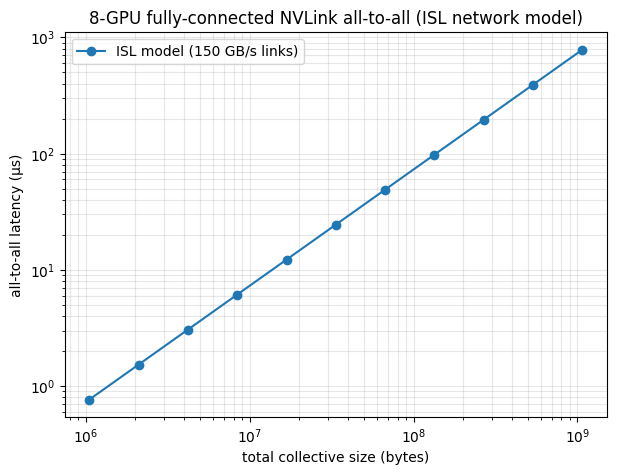

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(sweep["collective_size_bytes"], sweep["model_latency_s"] * 1e6, "o-",
          label=f"ISL model ({LINK_BW_GBPS:g} GB/s links)")
ax.set_xlabel("total collective size (bytes)")
ax.set_ylabel("all-to-all latency (µs)")
ax.set_title(f"{n}-GPU fully-connected NVLink all-to-all (ISL network model)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()  # ASTRA-sim 2.0 and EC2 nccl-tests series overlay here later
plt.show()

## Torus leg: 2×2×2 logical torus (3-cube) all-to-all

GPU $r$ sits at binary coordinates $(g_0, g_1, g_2) \in \{0, 1\}^3$ of a 3-dimensional `noc` space, one coordinate per torus dimension. Rank is recovered row-major with the **last** dimension fastest-varying, $r = 4g_0 + 2g_1 + g_2$ — matching the `torus_bench` benchmark's rank$\leftrightarrow$coordinate convention.

Every dimension here has extent 2, so the $\pm 1 \pmod 2$ torus wraparound edge coincides with the only other value that coordinate can take: wraparound degenerates exactly to the hypercube edge, and `HypercubeMulticastModel` applies directly. Its precondition — a Manhattan, translation-invariant `dist_fn` — is satisfied by Hamming distance on the binary coordinates (ISL has no `!=`/`<>` operator, so per-axis inequality is written as the disjunction `(a < b or a > b)`).

Cost per $(s, d)$ pair at Hamming distance $k$ is $2^k - 1$ (the bounding-box multicast-tree cost `HypercubeMulticastModel` computes), summing to **152** hops over all 64 `data[s, d]` chunks. A dimension-ordered *minimal unicast* routing — one packet per hop instead of a shared multicast tree, which is what the empirical torus benchmark actually implements — would instead traverse $\sum_{s,d} \mathrm{hamming}(s, d) = $ **96** hops. The two series bracket real routing behavior; the gap between them is itself a correlation observable, quantifying how far a multicast-aware model diverges from point-to-point unicast.

In [ ]:
def binary_bounds(prefix: str, k: int) -> str:
    """Bit constraints over dims ``{prefix}0..{prefix}{k-1}``."""
    return " and ".join(f"0 <= {prefix}{i} <= 1" for i in range(k))


def rank_expr(prefix: str, k: int) -> str:
    """Affine recovery of the rank from binary torus coordinates.

    Row-major with the LAST coordinate fastest-varying:
    ``rank = sum_i 2**(k-1-i) * g_i``, matching the ``torus_bench``
    benchmark's rank<->coordinate convention (see the markdown above).
    """
    return " + ".join(f"{2 ** (k - 1 - i)}*{prefix}{i}" for i in range(k))


def torus_all_to_all_maps(
    dims: tuple[int, ...] = (2, 2, 2),
) -> tuple[isl.Map, isl.Map, isl.Map]:
    """Build (occupancy, fill, dist_fn) for a logical-torus all-to-all.

    Mirrors ``all_to_all_maps`` above but keys GPUs by binary torus
    coordinates instead of a one-hot id. ``data[s, d]`` is the chunk sent
    by GPU ``s`` to GPU ``d``; each GPU holds the chunks it sends (occ)
    and requests the chunks addressed to it (fill).

    Parameters
    ----------
    dims : tuple of int, default (2, 2, 2)
        Per-dimension extents of the logical torus. Every entry must
        equal 2 (see Raises); ``K = len(dims)`` sets the dimensionality
        of the ``noc`` space and the number of ``SpatialTag`` axes the
        caller must build to match.

    Returns
    -------
    occ : isl.Map
        ``noc[g0..g_{K-1}] -> data[s, d]``: the GPU at ``(g0..g_{K-1})``
        holds the chunk it is the source of, for every destination ``d``.
    fill : isl.Map
        ``noc[g0..g_{K-1}] -> data[s, d]``: the GPU at ``(g0..g_{K-1})``
        requests the chunk addressed to it, for every source ``s``.
    dist_fn : isl.Map
        Piecewise Hamming distance between two ``noc`` points, encoded as
        a disjunction over the ``2**K`` equal/differ patterns per axis.

    Raises
    ------
    ValueError
        If any entry of ``dims`` is not 2. General (non-power-of-two)
        torus extents need a genuine wraparound-aware Manhattan distance
        function, not the hypercube-degeneracy shortcut used here — see
        the markdown cell above for why extent 2 is special.
    """
    if any(d != 2 for d in dims):
        raise ValueError(
            f"torus_all_to_all_maps only supports extent-2 dims (hypercube "
            f"wraparound degeneracy), got dims={dims!r}; general torus "
            f"extents need a wraparound-aware Manhattan dist_fn"
        )
    k = len(dims)
    n = 2 ** k

    gs = ", ".join(f"gs{i}" for i in range(k))
    gd = ", ".join(f"gd{i}" for i in range(k))
    occ = isl.Map.read_from_str(
        CTX,
        f"{{ noc[{gs}] -> data[s, d] : {binary_bounds('gs', k)} "
        f"and s = {rank_expr('gs', k)} and 0 <= d < {n} }}",
    )
    fill = isl.Map.read_from_str(
        CTX,
        f"{{ noc[{gd}] -> data[s, d] : {binary_bounds('gd', k)} "
        f"and d = {rank_expr('gd', k)} and 0 <= s < {n} }}",
    )

    # Piecewise Hamming distance: one disjunct per subset of axes that
    # differ (2**K sign patterns), cost = popcount of the subset. ISL has
    # no `!=`, so per-axis inequality is the disjunction (a < b or a > b).
    pieces = []
    for mask in range(2 ** k):
        dist = bin(mask).count("1")
        conds = [
            f"(gd{i} < gs{i} or gd{i} > gs{i})" if mask & (1 << i) else f"gd{i} = gs{i}"
            for i in range(k)
        ]
        pieces.append(
            f"[noc[{gd}] -> noc[{gs}]] -> hops[{dist}] : " + " and ".join(conds)
        )
    dist_fn = isl.Map.read_from_str(CTX, "{ " + "; ".join(pieces) + " }")

    return occ, fill, dist_fn

In [ ]:
dims_torus = (2, 2, 2)
k = len(dims_torus)
n_t = 2 ** k  # = 8 GPUs, same physical count as the FC leg above

occ_t, fill_t, dist_fn_t = torus_all_to_all_maps(dims_torus)
tags_t = [SpatialTag(i, 0) for i in range(k)]
model_t = HypercubeMulticastModel(dist_fn_t)


def torus_pair_hops(src: int, dst: int) -> int:
    """Hops for a single (src, dst) chunk under the torus (Hamming) dist_fn."""
    chunk = isl.Set.read_from_str(CTX, f"{{ data[{src}, {dst}] }}")
    info = model_t.apply(
        0,
        Fill(tags_t, fill_t.intersect_range(chunk)),
        Occupancy(tags_t, occ_t.intersect_range(chunk)),
    )
    return eval_total(info.hops)


def hamming(a: int, b: int) -> int:
    """Hamming distance between the binary representations of two ints."""
    return bin(a ^ b).count("1")


# --- Run the tool over the full all-to-all and validate against the
# verified reference numbers (see torus_hops_check.py pre-verification). ---
info_t = model_t.apply(0, Fill(tags_t, fill_t), Occupancy(tags_t, occ_t))
torus_hops = eval_total(info_t.hops)
assert torus_hops == 152, f"model returned {torus_hops} total hops, expected 152"

probes = {(0, 1): 1, (0, 3): 3, (0, 7): 7, (5, 5): 0}
for (src, dst), expected in probes.items():
    got = torus_pair_hops(src, dst)
    assert got == expected, f"pair ({src}->{dst}) cost {got} != {expected}"

# Dimension-ordered minimal unicast routing (what the empirical torus
# benchmark implements): one hop per differing bit, summed over every
# ordered (s, d) pair. Computed programmatically -- not hardcoded -- so
# it stays correct if dims_torus ever changes.
minroute_hops = sum(hamming(s, d) for s in range(n_t) for d in range(n_t))
assert minroute_hops == 96, f"minroute_hops {minroute_hops} != 96"

print(f"ISL network model: {n_t}-GPU 2x2x2 logical torus all-to-all (binary coords)")
print(f"  bounding-box multicast hops: {torus_hops} (Sigma 2^hamming(s,d) - 1)")
print(f"  min-route unicast hops     : {minroute_hops} (Sigma hamming(s,d))")
print(f"  routing gap                : {torus_hops - minroute_hops} hops "
      f"({torus_hops / minroute_hops:.2f}x)")

In [ ]:
# 8 nodes * 3 distinct neighbors/node. Extent-2 wraparound means the +1
# and -1 neighbor along a dim coincide (mod 2), so each node has exactly
# one neighbor per torus dimension, not two -- hence 3, not 6.
DIRECTED_LINKS_TORUS = n_t * k

rows_t = []
mib = MIN_MIB
while mib <= MAX_MIB:
    size = mib * (1 << 20)
    total = size * n_t if PER_RANK else size
    per_rank = total / n_t
    chunk_bytes = total / (n_t * n_t)
    # By symmetry, all-to-all traffic loads all 24 directed torus links
    # uniformly: total hop-bytes (chunk_bytes * hops, summed over the 64
    # chunks) divides evenly across the links. Two series bracket
    # routing: `torus_hops` (bounding-box multicast) vs. `minroute_hops`
    # (dimension-ordered unicast) -- see the markdown cell above.
    per_link_bytes_model = (torus_hops / DIRECTED_LINKS_TORUS) * chunk_bytes
    per_link_bytes_minroute = (minroute_hops / DIRECTED_LINKS_TORUS) * chunk_bytes
    model_latency_s = ALPHA_S + per_link_bytes_model / bw
    minroute_latency_s = ALPHA_S + per_link_bytes_minroute / bw
    # Closed-form cross-check: 152/(64*24) = 19/192, 96/(64*24) = 1/16.
    assert math.isclose(model_latency_s, ALPHA_S + total * 19 / (192 * bw), rel_tol=1e-12)
    assert math.isclose(minroute_latency_s, ALPHA_S + total / (16 * bw), rel_tol=1e-12)
    rows_t.append((n_t, int(total), int(per_rank), per_link_bytes_model,
                    model_latency_s, minroute_latency_s))
    mib *= 2

sweep_torus = pd.DataFrame(rows_t, columns=[
    "nodes", "collective_size_bytes", "per_rank_bytes", "per_link_bytes_model",
    "model_latency_s", "minroute_latency_s",
])
sweep_torus

## Empirical overlay: EC2 nccl-tests + torus_bench

CSV files under `correlation/data/` (e.g. `correlation/data/<run>/csv/*.csv`) are fetched by `correlation/orchestrate.py` (sibling infrastructure, not part of this notebook) and share a unified schema: `source, topology, dims, collective, size_bytes, count, dtype, time_us, algbw_GBps, busbw_GBps, wrong`.

Size normalization to the total collective size $S$ used by `sweep` / `sweep_torus` above differs by source: for `source == "torus_bench"` rows, `size_bytes` is **already** the total $S$. For `source == "nccl-tests"` rows with `collective == "alltoall"`, `size_bytes` is the *per-rank* message size, so $S = N \times \texttt{size\_bytes}$ — verify this against the nccl-tests version actually in use, since the size semantics nccl-tests reports differ per collective. Only `alltoall` is normalized and correlated against the model here; other collectives are inventoried below for later work.

In [ ]:
from pathlib import Path

# Design: prefer the path relative to the notebook's own directory (the
# normal case when the notebook is run in place), but fall back to the
# repo-root-relative path so `jupyter execute` from a different cwd (e.g.
# CI running from the repo root) still finds real data when it exists,
# instead of silently taking the empty-data path below.
DATA_DIR = (
    Path("correlation/data") if Path("correlation").is_dir()
    else Path("notebooks/astrasim2_correlation/correlation/data")
)

UNIFIED_CSV_COLUMNS = [
    "source", "topology", "dims", "collective", "size_bytes", "count",
    "dtype", "time_us", "algbw_GBps", "busbw_GBps", "wrong",
]
_NUMERIC_COLUMNS = ["size_bytes", "count", "time_us", "algbw_GBps", "busbw_GBps"]

files = sorted(DATA_DIR.glob("**/*.csv"))
if files:
    emp = pd.concat(
        [pd.read_csv(f, dtype={"wrong": str}) for f in files],
        ignore_index=True,
    )
    for col in _NUMERIC_COLUMNS:
        emp[col] = pd.to_numeric(emp[col], errors="coerce")
else:
    # Design: keep the unified schema even when no files were found, so
    # downstream cells can reference emp[...] columns inside their
    # `if HAVE_EMPIRICAL:` guards without ever hitting a KeyError.
    emp = pd.DataFrame(columns=UNIFIED_CSV_COLUMNS)

HAVE_EMPIRICAL = len(files) > 0 and not emp.empty

if not HAVE_EMPIRICAL:
    print("no empirical data yet -- run correlation/orchestrate.py; "
          "overlay cells below will no-op")
else:
    inventory = emp.groupby(["topology", "collective"]).agg(
        rows=("size_bytes", "count"),
        min_size=("size_bytes", "min"),
        max_size=("size_bytes", "max"),
    )
    display(inventory)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(sweep["collective_size_bytes"], sweep["model_latency_s"] * 1e6, "o-",
          label=f"FC model ({LINK_BW_GBPS:g} GB/s links)")
ax.loglog(sweep_torus["collective_size_bytes"], sweep_torus["model_latency_s"] * 1e6, "s-",
          label="torus model, 152 hops (bounding-box multicast)")
ax.loglog(sweep_torus["collective_size_bytes"], sweep_torus["minroute_latency_s"] * 1e6, "s--",
          label="torus min-route, 96 hops (dimension-ordered unicast)")

if HAVE_EMPIRICAL:
    alltoall = emp[emp["collective"] == "alltoall"]
    fc_rows = alltoall[alltoall["topology"] == "fc"]
    torus_rows = alltoall[alltoall["topology"] == "torus"]
    if not fc_rows.empty:
        # nccl-tests alltoall size_bytes is the PER-RANK message size (see
        # markdown above); scale to total S to match `sweep`'s convention.
        ax.scatter(fc_rows["size_bytes"] * NODES, fc_rows["time_us"],
                   marker="x", color="tab:red", label="EC2 nccl-tests alltoall (fc)")
    if not torus_rows.empty:
        # torus_bench size_bytes is ALREADY total collective size S.
        ax.scatter(torus_rows["size_bytes"], torus_rows["time_us"],
                   marker="+", color="tab:green", label="EC2 torus_bench alltoall (torus)")

ax.set_xlabel("total collective size (bytes)")
ax.set_ylabel("all-to-all latency (µs)")
ax.set_title("Fully-connected vs. 2x2x2 torus all-to-all: model vs. empirical")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

In [ ]:
import numpy as np


def linear_fit(S: np.ndarray, t: np.ndarray) -> tuple[float, float, float]:
    """Ordinary-least-squares fit of ``t = intercept + slope * S``.

    Parameters
    ----------
    S : np.ndarray
        Total collective size in bytes for each empirical sample.
    t : np.ndarray
        Measured latency in seconds for each empirical sample. Must be
        the same length as `S`.

    Returns
    -------
    intercept : float
        Fitted per-operation latency overhead (the model's alpha), seconds.
    slope : float
        Fitted dt/dS, seconds/byte.
    r_squared : float
        Coefficient of determination of the linear fit; NaN if `t` has
        zero total variance (R^2 is undefined in that degenerate case).
    """
    slope, intercept = np.polyfit(S, t, 1)
    t_pred = slope * S + intercept
    ss_res = float(np.sum((t - t_pred) ** 2))
    ss_tot = float(np.sum((t - np.mean(t)) ** 2))
    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return float(intercept), float(slope), r_squared


def bw_from_slope(slope: float, slope_factor: float) -> float:
    """Translate a fitted t-vs-S slope into an effective bandwidth, bytes/s.

    Given the model form ``t = alpha + S * slope_factor / BW``, the
    fitted slope is ``dt/dS = slope_factor / BW``, so
    ``BW = slope_factor / slope``.
    """
    return slope_factor / slope


if HAVE_EMPIRICAL and (emp["collective"] == "alltoall").any():
    alltoall = emp[emp["collective"] == "alltoall"].dropna(
        subset=["size_bytes", "time_us"]
    )

    fc_rows = alltoall[alltoall["topology"] == "fc"]
    if len(fc_rows) >= 2:
        # fc slope_factor = (N-1)/N^2 = 7/64 (N=8), from the closed form
        # in the "Size and latency conventions" cell above.
        S_fc = fc_rows["size_bytes"].to_numpy(dtype=float) * NODES
        t_fc = fc_rows["time_us"].to_numpy(dtype=float) * 1e-6
        alpha_fc, slope_fc, r2_fc = linear_fit(S_fc, t_fc)
        bw_fc = bw_from_slope(slope_fc, 7 / 64)
        print(f"FC calibration    : alpha = {alpha_fc * 1e6:.3f} us, "
              f"BW_eff = {bw_fc / 1e9:.2f} GB/s, R^2 = {r2_fc:.4f}")
    else:
        print("FC calibration    : fewer than 2 alltoall rows, skipping fit")

    torus_rows = alltoall[alltoall["topology"] == "torus"]
    if len(torus_rows) >= 2:
        # torus slope_factor = hops/(64*24) = hops/1536; report BW under
        # both routing hypotheses (h=152 bounding-box, h=96 min-route)
        # from a single fit, since alpha/R^2 don't depend on slope_factor
        # -- only the slope-to-BW translation does.
        S_t = torus_rows["size_bytes"].to_numpy(dtype=float)
        t_t = torus_rows["time_us"].to_numpy(dtype=float) * 1e-6
        alpha_t, slope_t, r2_t = linear_fit(S_t, t_t)
        bw_t_152 = bw_from_slope(slope_t, 152 / 1536)
        bw_t_96 = bw_from_slope(slope_t, 96 / 1536)
        print(f"torus calibration : alpha = {alpha_t * 1e6:.3f} us, R^2 = {r2_t:.4f}")
        print(f"  BW_eff @ h=152 (bounding-box model): {bw_t_152 / 1e9:.2f} GB/s")
        print(f"  BW_eff @ h=96  (dimension-ordered)  : {bw_t_96 / 1e9:.2f} GB/s")
    else:
        print("torus calibration : fewer than 2 alltoall rows, skipping fit")
else:
    print("calibration: no empirical alltoall rows yet")